In [1]:
# Import Libraries
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import nltk

In [2]:
# Download NLTK Resources
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...


True

In [3]:
from google.colab import files

uploaded = files.upload()

Saving IMDB Dataset.csv to IMDB Dataset.csv


In [4]:
# Load Dataset
df = pd.read_csv("IMDB Dataset.csv")

df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [5]:
# Dataset Information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [6]:
# Missing Values
df.isnull().sum()

,0
review,0
sentiment,0


In [7]:
# Dataset Shape
print("Rows and Columns:", df.shape)

Rows and Columns: (50000, 2)


In [8]:
# Duplicate Reviews
print("Duplicate Reviews:", df.duplicated().sum())

Duplicate Reviews: 418


In [9]:
# Sentiment Counts
df["sentiment"].value_counts()

,count
sentiment,
positive,25000
negative,25000


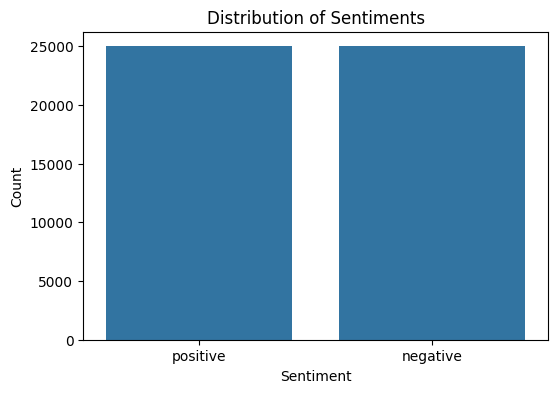

In [10]:
# Sentiment Distribution
plt.figure(figsize=(6,4))

sns.countplot(
    data=df,
    x="sentiment"
)

plt.title("Distribution of Sentiments")

plt.xlabel("Sentiment")
plt.ylabel("Count")

plt.show()

In [11]:
# Review Length
df["review_length"] = df["review"].apply(len)

df["review_length"].describe()

,review_length
count,50000.000000
mean,1308.114440
std,989.661099
min,32.000000
25%,698.000000
50%,969.500000
75%,1588.000000
max,13704.000000


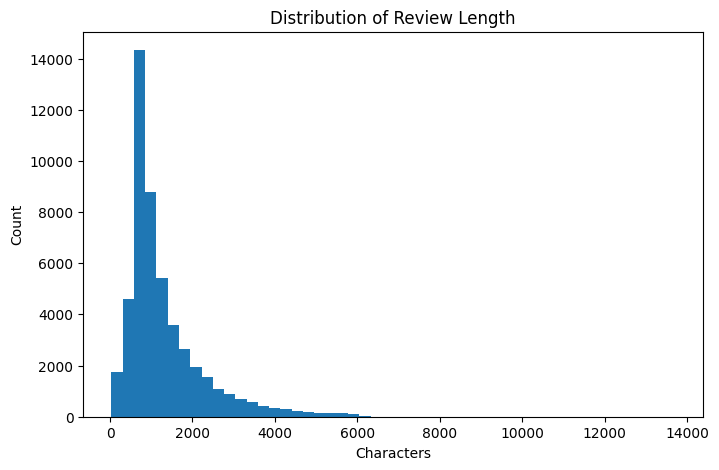

In [12]:
# Review Length Distribution
plt.figure(figsize=(8,5))

plt.hist(
    df["review_length"],
    bins=50
)

plt.title("Distribution of Review Length")

plt.xlabel("Characters")

plt.ylabel("Count")

plt.show()

In [ ]:
# Dataset Loading and Initial Exploration

# The IMDb Movie Reviews dataset containing 50,000 labeled reviews was loaded into Google Colab.

# Initial exploration included checking the dataset structure, identifying missing values, detecting duplicate reviews, examining sentiment distribution, and analyzing review lengths.

# These steps ensure that the dataset is suitable for Natural Language Processing before text preprocessing begins.

In [13]:
# Remove Duplicate Reviews
df = df.drop_duplicates()

print("Dataset Shape After Removing Duplicates:")
print(df.shape)

Dataset Shape After Removing Duplicates:
(49582, 3)


In [14]:
# Verify Duplicates
print("Remaining Duplicates:", df.duplicated().sum())

Remaining Duplicates: 0


In [15]:
# Sample Positive Review
print("Positive Review:\n")
print(df[df["sentiment"]=="positive"]["review"].iloc[0])

Positive Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [16]:
# Sample Negative Review
print("\nNegative Review:\n")
print(df[df["sentiment"]=="negative"]["review"].iloc[0])


Negative Review:

Basically there's a family where a little boy (Jake) thinks there's a zombie in his closet & his parents are fighting all the time.<br /><br />This movie is slower than a soap opera... and suddenly, Jake decides to become Rambo and kill the zombie.<br /><br />OK, first of all when you're going to make a film you must Decide if its a thriller or a drama! As a drama the movie is watchable. Parents are divorcing & arguing like in real life. And then we have Jake with his closet which totally ruins all the film! I expected to see a BOOGEYMAN similar movie, and instead i watched a drama with some meaningless thriller spots.<br /><br />3 out of 10 just for the well playing parents & descent dialogs. As for the shots with Jake: just ignore them.


In [17]:
# Word Count
df["word_count"] = df["review"].apply(lambda x: len(x.split()))

df["word_count"].describe()

,word_count
count,49582.000000
mean,231.111069
std,171.514326
min,4.000000
25%,126.000000
50%,173.000000
75%,280.000000
max,2470.000000


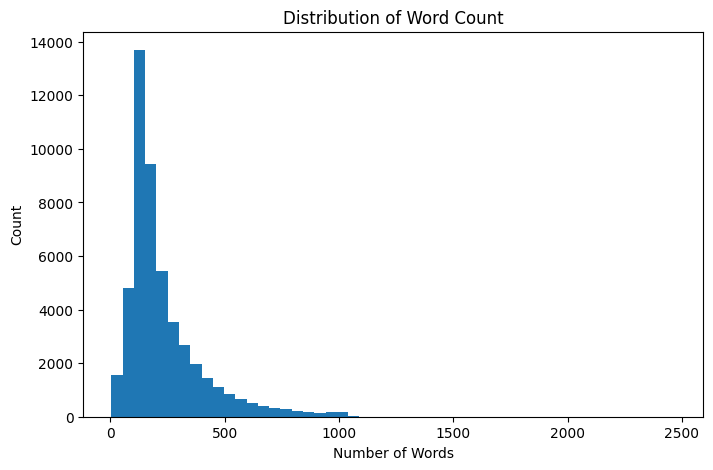

In [18]:
# Word Count Distribution
plt.figure(figsize=(8,5))

plt.hist(
    df["word_count"],
    bins=50
)

plt.title("Distribution of Word Count")

plt.xlabel("Number of Words")

plt.ylabel("Count")

plt.show()

In [19]:
# Shortest Reviews
df.nsmallest(5, "word_count")[["review", "sentiment", "word_count"]]

,review,sentiment,word_count
28920,Primary plot!Primary direction!Poor interpreta...,negative,4
27521,"Read the book, forget the movie!",negative,6
13109,"More suspenseful, more subtle, much, much more...",negative,8
40817,I hope this group of film-makers never re-unites.,negative,8
31072,"What a script, what a story, what a mess!",negative,9


In [20]:
# Longest Reviews
df.nlargest(5, "word_count")[["review", "sentiment", "word_count"]]

,review,sentiment,word_count
31481,Match 1: Tag Team Table Match Bubba Ray and Sp...,positive,2470
40521,There's a sign on The Lost Highway that says:<...,positive,2278
31436,"Back in the mid/late 80s, an OAV anime by titl...",positive,2125
31240,"(Some spoilers included:)<br /><br />Although,...",positive,2108
12647,Titanic directed by James Cameron presents a f...,positive,1839


In [21]:
# Average Word Count
df.groupby("sentiment")["word_count"].mean()

,word_count
sentiment,
negative,229.368734
positive,232.840379


In [ ]:
# Exploratory Data Analysis

# Duplicate reviews were removed to improve data quality. The dataset was then explored by examining review lengths, displaying sample reviews, and comparing the average number of words across positive and negative sentiments.

# These observations help in understanding the text before building the preprocessing pipeline.

In [26]:
import nltk

nltk.download("punkt")
nltk.download("punkt_tab")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to /root/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [27]:
# Import NLP Libraries
import re
import string

from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

In [28]:
# Initialize Stop Words & Lemmatizer
stop_words = set(stopwords.words("english"))

lemmatizer = WordNetLemmatizer()

In [29]:
# Text Cleaning Function
def clean_text(text):

    # Convert to lowercase
    text = text.lower()

    # Remove HTML tags
    text = re.sub(r"<.*?>", "", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", "", text)

    # Remove numbers
    text = re.sub(r"\d+", "", text)

    # Remove punctuation
    text = text.translate(str.maketrans("", "", string.punctuation))

    # Tokenization
    tokens = word_tokenize(text)

    # Remove stop words and short words
    tokens = [
        word for word in tokens
        if word not in stop_words and len(word) > 2
    ]

    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]

    # Join back into sentence
    return " ".join(tokens)

In [30]:
# Apply Text Cleaning
df["clean_review"] = df["review"].apply(clean_text)

In [31]:
# Compare Reviews
print("Original Review:\n")
print(df["review"].iloc[0])

print("\n" + "="*100 + "\n")

print("Cleaned Review:\n")
print(df["clean_review"].iloc[0])

Original Review:

One of the other reviewers has mentioned that after watching just 1 Oz episode you'll be hooked. They are right, as this is exactly what happened with me.<br /><br />The first thing that struck me about Oz was its brutality and unflinching scenes of violence, which set in right from the word GO. Trust me, this is not a show for the faint hearted or timid. This show pulls no punches with regards to drugs, sex or violence. Its is hardcore, in the classic use of the word.<br /><br />It is called OZ as that is the nickname given to the Oswald Maximum Security State Penitentary. It focuses mainly on Emerald City, an experimental section of the prison where all the cells have glass fronts and face inwards, so privacy is not high on the agenda. Em City is home to many..Aryans, Muslims, gangstas, Latinos, Christians, Italians, Irish and more....so scuffles, death stares, dodgy dealings and shady agreements are never far away.<br /><br />I would say the main appeal of the show

In [32]:
# Empty Reviews
empty_reviews = (df["clean_review"].str.len() == 0).sum()

print("Empty Reviews:", empty_reviews)

Empty Reviews: 0


In [33]:
# Review Length Comparison
df["clean_length"] = df["clean_review"].apply(len)

print(df[["review_length", "clean_length"]].describe())

       review_length  clean_length
count   49582.000000  49582.000000
mean     1309.252793    815.413396
std       990.687068    630.220398
min        32.000000     17.000000
25%       699.000000    426.000000
50%       970.000000    599.000000
75%      1590.000000    992.750000
max     13704.000000   9107.000000


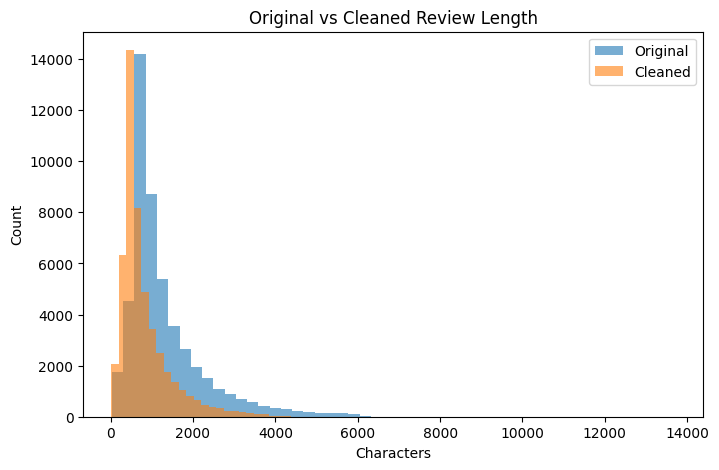

In [34]:
# Length Comparison
plt.figure(figsize=(8,5))

plt.hist(
    df["review_length"],
    bins=50,
    alpha=0.6,
    label="Original"
)

plt.hist(
    df["clean_length"],
    bins=50,
    alpha=0.6,
    label="Cleaned"
)

plt.legend()

plt.title("Original vs Cleaned Review Length")

plt.xlabel("Characters")

plt.ylabel("Count")

plt.show()

In [35]:
# View Dataset
df.head()

,review,sentiment,review_length,word_count,clean_review,clean_length
0,One of the other reviewers has mentioned that ...,positive,1761,307,one reviewer mentioned watching episode youll ...,1104
1,A wonderful little production. <br /><br />The...,positive,998,162,wonderful little production filming technique ...,640
2,I thought this was a wonderful way to spend ti...,positive,926,166,thought wonderful way spend time hot summer we...,572
3,Basically there's a family where a little boy ...,negative,748,138,basically there family little boy jake think t...,446
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive,1317,230,petter matteis love time money visually stunni...,838


In [36]:
# Save Cleaned Dataset
df.to_csv("IMDB_Cleaned.csv", index=False)

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


In [ ]:
# Text Preprocessing

# In this phase, a complete NLP preprocessing pipeline was developed. The reviews were converted to lowercase, HTML tags, URLs, numbers, and punctuation were removed, the text was tokenized, English stop words were filtered out, and the remaining words were lemmatized.

# The cleaned reviews were stored in a new column (`clean_review`), making the dataset ready for TF-IDF vectorization and machine learning.

In [37]:
# Import TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

In [38]:
# Create TF-IDF Vectorizer
tfidf = TfidfVectorizer(
    max_features=5000,
    min_df=5,
    max_df=0.8
)

In [39]:
# Convert Text into TF-IDF Matrix

X = tfidf.fit_transform(df["clean_review"])

In [40]:
# Encode Sentiment Labels

from sklearn.preprocessing import LabelEncoder

encoder = LabelEncoder()

y = encoder.fit_transform(df["sentiment"])

In [41]:
# TF-IDF Matrix Shape

print("TF-IDF Shape:", X.shape)

TF-IDF Shape: (49582, 5000)


In [42]:
# Encoded Labels

print("Classes:", encoder.classes_)

print("First 10 Labels:")

print(y[:10])

Classes: ['negative' 'positive']
First 10 Labels:
[1 1 1 0 1 1 1 0 0 1]


In [43]:
# Vocabulary Size

print("Vocabulary Size:", len(tfidf.vocabulary_))

Vocabulary Size: 5000


In [44]:
# Sample Vocabulary

feature_names = tfidf.get_feature_names_out()

print(feature_names[:30])

['aaron' 'abandoned' 'abc' 'ability' 'able' 'abrupt' 'absence' 'absent'
 'absolute' 'absolutely' 'absurd' 'absurdity' 'abuse' 'abused' 'abusive'
 'abysmal' 'academy' 'accent' 'accept' 'acceptable' 'acceptance'
 'accepted' 'access' 'accident' 'accidentally' 'acclaimed' 'accompanied'
 'accomplish' 'accomplished' 'according']


In [ ]:
# TF-IDF Vectorization

# The cleaned reviews were transformed into numerical feature vectors using TF-IDF (Term Frequency–Inverse Document Frequency). This technique converts text into mathematical representations while emphasizing informative words and reducing the influence of extremely common or rare terms.

# The sentiment labels were also encoded into numerical values to prepare the data for machine learning model training.

In [45]:
# Import Train-Test Split

from sklearn.model_selection import train_test_split

In [46]:
# Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [47]:
# Dataset Shapes

print("Training Features :", X_train.shape)
print("Testing Features  :", X_test.shape)

print()

print("Training Labels :", y_train.shape)
print("Testing Labels  :", y_test.shape)

Training Features : (39665, 5000)
Testing Features  : (9917, 5000)

Training Labels : (39665,)
Testing Labels  : (9917,)


In [48]:
# Class Distribution

import pandas as pd

print("Training Set")

print(pd.Series(y_train).value_counts())

print()

print("Testing Set")

print(pd.Series(y_test).value_counts())

Training Set
1    19907
0    19758
Name: count, dtype: int64

Testing Set
1    4977
0    4940
Name: count, dtype: int64


In [ ]:
# Train-Test Split

# The TF-IDF feature matrix and encoded sentiment labels were divided into training and testing sets using an 80:20 ratio. Stratified sampling was applied to preserve the equal distribution of positive and negative reviews in both subsets.

# This prepares the data for training and evaluating sentiment classification models.

In [49]:
# Import Machine Learning Models

from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

In [50]:
# Train Naive Bayes
nb_model = MultinomialNB()

nb_model.fit(X_train, y_train)

print("Naive Bayes Model Trained Successfully!")

Naive Bayes Model Trained Successfully!


In [51]:
# Train Linear SVM

svm_model = LinearSVC(random_state=42)

svm_model.fit(X_train, y_train)

print("Linear SVM Model Trained Successfully!")

Linear SVM Model Trained Successfully!


In [52]:
# Naive Bayes Predictions

nb_predictions = nb_model.predict(X_test)

In [53]:
# Linear SVM Predictions

svm_predictions = svm_model.predict(X_test)

In [54]:
# Prediction Shapes

print("Naive Bayes Predictions:", nb_predictions.shape)

print("Linear SVM Predictions:", svm_predictions.shape)

Naive Bayes Predictions: (9917,)
Linear SVM Predictions: (9917,)


In [ ]:
# Model Training

# Two supervised machine learning models were trained using the TF-IDF feature matrix:

# - Multinomial Naive Bayes
# - Linear Support Vector Machine (Linear SVM)

# The trained models were then used to predict the sentiments of the unseen test reviews, preparing them for performance evaluation.

In [55]:
# Import Evaluation Metrics

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

import matplotlib.pyplot as plt
import seaborn as sns

In [56]:
# Naive Bayes Evaluation

print("========== Naive Bayes ==========\n")

print("Accuracy :", accuracy_score(y_test, nb_predictions))
print("Precision:", precision_score(y_test, nb_predictions))
print("Recall   :", recall_score(y_test, nb_predictions))
print("F1 Score :", f1_score(y_test, nb_predictions))

print("\nClassification Report:\n")

print(classification_report(y_test, nb_predictions))

========== Naive Bayes ==========

Accuracy : 0.8508621558939196
Precision: 0.8475755166931638
Recall   : 0.8569419328912999
F1 Score : 0.8522329903087221

Classification Report:

              precision    recall  f1-score   support

           0       0.85      0.84      0.85      4940
           1       0.85      0.86      0.85      4977

    accuracy                           0.85      9917
   macro avg       0.85      0.85      0.85      9917
weighted avg       0.85      0.85      0.85      9917



In [57]:
# Linear SVM Evaluation

print("========== Linear SVM ==========\n")

print("Accuracy :", accuracy_score(y_test, svm_predictions))
print("Precision:", precision_score(y_test, svm_predictions))
print("Recall   :", recall_score(y_test, svm_predictions))
print("F1 Score :", f1_score(y_test, svm_predictions))

print("\nClassification Report:\n")

print(classification_report(y_test, svm_predictions))

========== Linear SVM ==========

Accuracy : 0.8766764142381769
Precision: 0.8754
Recall   : 0.8794454490657022
F1 Score : 0.8774180615415456

Classification Report:

              precision    recall  f1-score   support

           0       0.88      0.87      0.88      4940
           1       0.88      0.88      0.88      4977

    accuracy                           0.88      9917
   macro avg       0.88      0.88      0.88      9917
weighted avg       0.88      0.88      0.88      9917



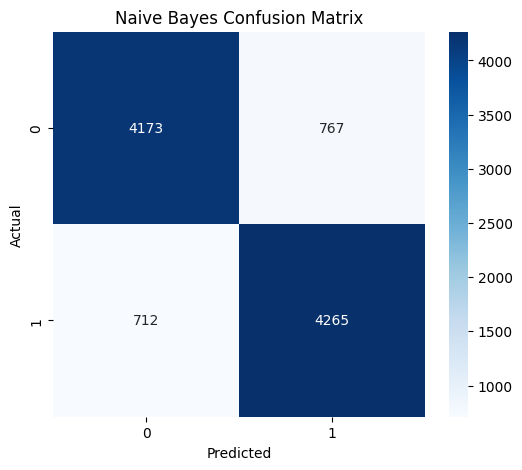

In [58]:
# Confusion Matrix - Naive Bayes

cm_nb = confusion_matrix(y_test, nb_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_nb,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Naive Bayes Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

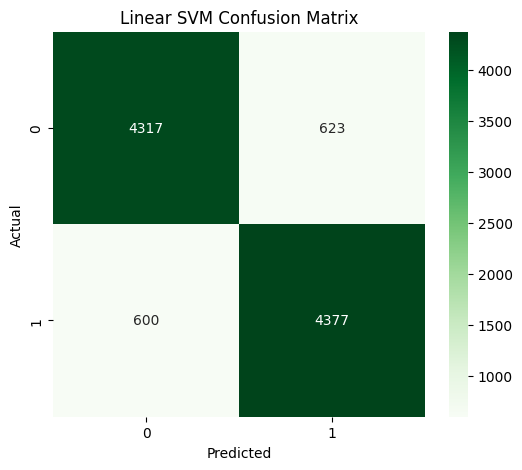

In [59]:
# Confusion Matrix - Linear SVM

cm_svm = confusion_matrix(y_test, svm_predictions)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    cmap="Greens"
)

plt.title("Linear SVM Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [60]:
# Model Comparison

comparison = {
    "Model": ["Naive Bayes", "Linear SVM"],
    "Accuracy": [
        accuracy_score(y_test, nb_predictions),
        accuracy_score(y_test, svm_predictions)
    ],
    "Precision": [
        precision_score(y_test, nb_predictions),
        precision_score(y_test, svm_predictions)
    ],
    "Recall": [
        recall_score(y_test, nb_predictions),
        recall_score(y_test, svm_predictions)
    ],
    "F1 Score": [
        f1_score(y_test, nb_predictions),
        f1_score(y_test, svm_predictions)
    ]
}

comparison_df = pd.DataFrame(comparison)

comparison_df

,Model,Accuracy,Precision,Recall,F1 Score
0,Naive Bayes,0.850862,0.847576,0.856942,0.852233
1,Linear SVM,0.876676,0.875400,0.879445,0.877418


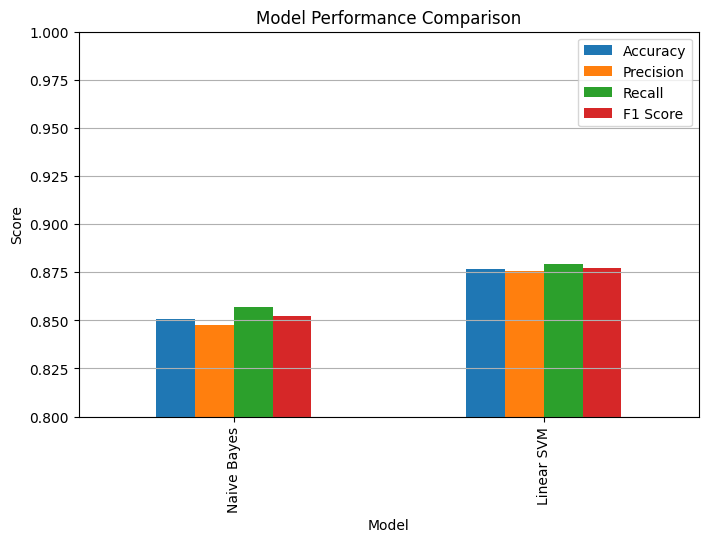

In [61]:
# Compare Model Performance

comparison_df.set_index("Model").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")

plt.ylim(0.80, 1.00)

plt.grid(axis="y")

plt.show()

In [ ]:
# Model Evaluation

# Both machine learning models were evaluated using standard classification metrics including Accuracy, Precision, Recall, and F1-Score.

# Confusion matrices were generated to visualize the classification performance, and a comparison table was created to determine which model achieved better sentiment prediction performance.

In [62]:
# Test Custom Reviews

sample_reviews = [
    "This movie was absolutely amazing. I loved every minute of it.",
    "Worst movie ever. Total waste of time.",
    "The acting was decent but the story was boring.",
    "Fantastic visuals and excellent acting.",
    "I will never watch this movie again."
]

sample_vectors = tfidf.transform(sample_reviews)

predictions = svm_model.predict(sample_vectors)

for review, pred in zip(sample_reviews, predictions):
    sentiment = "Positive 😊" if pred == 1 else "Negative 😞"

    print("Review:", review)
    print("Prediction:", sentiment)
    print("-"*60)

Review: This movie was absolutely amazing. I loved every minute of it.
Prediction: Positive 😊
------------------------------------------------------------
Review: Worst movie ever. Total waste of time.
Prediction: Negative 😞
------------------------------------------------------------
Review: The acting was decent but the story was boring.
Prediction: Negative 😞
------------------------------------------------------------
Review: Fantastic visuals and excellent acting.
Prediction: Positive 😊
------------------------------------------------------------
Review: I will never watch this movie again.
Prediction: Positive 😊
------------------------------------------------------------


In [63]:
import joblib

joblib.dump(svm_model, "sentiment_model.pkl")

print("Model Saved Successfully!")

Model Saved Successfully!


In [64]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("Vectorizer Saved Successfully!")

Vectorizer Saved Successfully!


In [65]:
loaded_model = joblib.load("sentiment_model.pkl")

loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

print("Files Loaded Successfully!")

Files Loaded Successfully!


In [66]:
new_review = [
    "The movie was fantastic and I enjoyed every scene."
]

new_vector = loaded_vectorizer.transform(new_review)

prediction = loaded_model.predict(new_vector)

if prediction[0] == 1:
    print("Prediction: Positive 😊")
else:
    print("Prediction: Negative 😞")

Prediction: Positive 😊


In [67]:
from google.colab import files

files.download("sentiment_model.pkl")
files.download("tfidf_vectorizer.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
# Project Conclusion

# This project successfully developed a sentiment analysis system using Natural Language Processing (NLP).

# Major tasks completed:

# - Performed exploratory data analysis on the IMDB movie reviews dataset.
# - Built a complete text preprocessing pipeline including tokenization, stop-word removal, and lemmatization.
# - Converted textual reviews into numerical features using TF-IDF vectorization.
# - Trained two machine learning models: Multinomial Naive Bayes and Linear SVM.
# - Evaluated the models using Accuracy, Precision, Recall, and F1-Score.
# - Linear SVM achieved the best performance with approximately 87.7% accuracy.
# - Saved the trained model and TF-IDF vectorizer for future predictions.

# This project demonstrates a complete NLP workflow from raw text preprocessing to model deployment.